# Notebook 3: Business Utility@K Evaluation

**Goal (RQ2/RQ3 from the proposal):** Measure whether the coupon recommendation list is *economically useful* — not just accurate — by computing Business Utility@K as defined in the proposal.

Run **after** notebook 1, which writes `outputs/reranked_recommendations.csv`.

## Formula

$$\text{BusinessUtility@K} = \sum_{\text{ground-truth hits in top-K}} \left(\text{revenue} - \text{discount\_cost}\right)$$

averaged over events that have at least one ground-truth hit in the top-K list.

Where:
- **revenue** = 1.0 per purchased item (binary proxy — dataset has no product-level margin data)
- **discount\_cost** = `discount_signal × recommend_coupon` per hit item

This is the revenue-minus-discount-cost formula from the proposal, evaluated on ground-truth hits only. We do not claim to optimise real profit because the dataset does not include product cost or true margin.

## What `discount_signal` captures

The `discount_signal` column in `reranked_recommendations.csv` encodes the historical ratio of retail discount and coupon discount for a product relative to its household's purchase history. It is already normalised to [0, 1] and was included in the XGBoost feature set (though XGBoost assigned it zero importance, meaning the *ranking* did not use it — but it is still a valid cost proxy for *post-hoc* business utility measurement).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUTS = "../outputs"

recs  = pd.read_csv(f"{OUTPUTS}/reranked_recommendations.csv")
truth = pd.read_csv(f"{OUTPUTS}/coupon_response_all_truth.csv")

print(f"Recommendations: {len(recs):,} rows | splits: {recs['split'].unique()}")
print(f"Truth items: {len(truth):,} rows")

Recommendations: 44,760 rows | splits: <StringArray>
['validation', 'test']
Length: 2, dtype: str
Truth items: 18,203 rows


## 1. Quick sanity check on the loaded data

In [2]:
# Events per split
print(recs.groupby("split")["event_id"].nunique().rename("unique events"), "\n")

# Positive events: events where at least one item was purchased within 5 days
positive_events = (
    recs[recs["success_within_5d_observed"]]
    .groupby("split")["event_id"]
    .nunique()
    .rename("positive events")
)
print(positive_events)

# Coupon-recommended items and their average discount signal
print("\nAverage discount_signal by recommend_coupon flag:")
print(recs.groupby("recommend_coupon")["discount_signal"].describe())

split
test           715
validation    1523
Name: unique events, dtype: int64 

split
test           68
validation    519
Name: positive events, dtype: int64

Average discount_signal by recommend_coupon flag:
                    count      mean       std  min       25%       50%  \
recommend_coupon                                                         
True              44760.0  0.050859  0.079406  0.0  0.003277  0.017613   

                       75%  max  
recommend_coupon                 
True              0.060888  1.0  


## 2. Business Utility helper functions

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_ROOT = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_ROOT))

from promomind.evaluation.business import business_utility_at_k as _bu_lib

def business_utility_at_k(df, k, split="test"):
    """
    Proposal formula: revenue minus discount cost, ground-truth hits only.
    Delegates to promomind.evaluation.business.business_utility_at_k.
    """
    sub = df[df["split"] == split].copy()
    sub["expected_revenue"] = 1.0
    sub["discount_cost"] = sub["discount_signal"] * sub["recommend_coupon"].astype(float)
    truth_split = truth[truth["event_id"].isin(sub["event_id"].unique())]
    return _bu_lib(
        sub,
        ground_truth=truth_split,
        k=k,
        user_col="event_id",
        item_col="product_id",
        revenue_col="expected_revenue",
        discount_col="discount_cost",
    )


def business_utility_sensitivity(df, k=10, discount_weights=(0.0, 0.5, 1.0, 2.0), split="test"):
    """
    Exploratory: vary the discount cost weight to show the trade-off.
    The canonical BU is business_utility_at_k (weight=1.0).
    """
    sub = df[df["split"] == split].copy()
    truth_split = truth[truth["event_id"].isin(sub["event_id"].unique())]
    sub = sub.merge(
        truth_split[["event_id", "product_id"]].drop_duplicates().assign(_hit=True),
        on=["event_id", "product_id"], how="left",
    )
    hits = sub[sub["_hit"].fillna(False)].copy()
    if hits.empty:
        return {w: 0.0 for w in discount_weights}
    hits["discount_cost"] = hits["discount_signal"] * hits["recommend_coupon"].astype(float)
    per_event = hits.groupby("event_id").agg(
        n_hits=("_hit", "sum"), discount_cost=("discount_cost", "sum")
    )
    return {w: float((per_event["n_hits"] - w * per_event["discount_cost"]).mean())
            for w in discount_weights}


def business_utility_table(df, k_values=(5, 10, 20), split="test"):
    rows = []
    for k in k_values:
        bu = business_utility_at_k(df, k=k, split=split)
        rows.append({"K": k, "BU@K": round(bu, 4)})
    return pd.DataFrame(rows).set_index("K")

## 3. Business Utility@K table (test split)

In [4]:
bu_table = business_utility_table(recs, split="test")
print("Business Utility@K — test split (proposal formula: revenue - discount_cost, ground-truth hits)")
print(bu_table.to_string())

Business Utility@K — test split (proposal formula: revenue - discount_cost, ground-truth hits)
      BU@K
K         
5   1.1501
10  1.2638
20  1.3898


## 4. Sensitivity analysis: Business Utility@10 vs the discount-cost weight

We vary **w**, the weight on discount cost *in the BU metric* (how harshly we price coupon spend), while holding the recommendation list fixed. `w` is an accounting/reporting knob for the metric — **distinct from the reranking λ in notebook 1**, which actually reorders the list. Varying `w` does not change the recommendations, only how we score them.

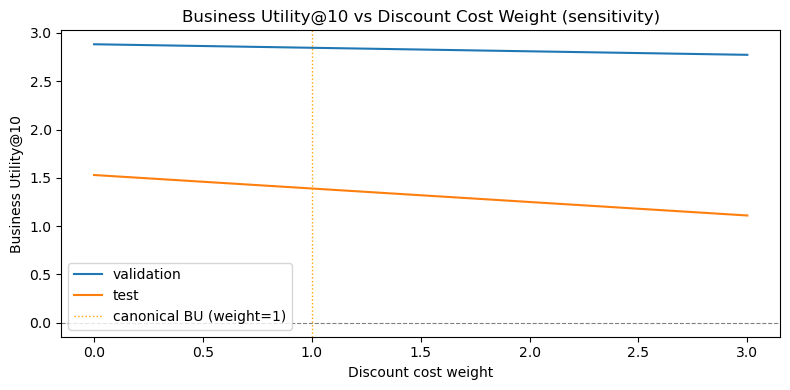

In [5]:
discount_weights = np.linspace(0, 3, 61)

fig, ax = plt.subplots(figsize=(8, 4))
for split in ["validation", "test"]:
    bus = [business_utility_sensitivity(recs, k=10, discount_weights=[w], split=split)[w]
           for w in discount_weights]
    ax.plot(discount_weights, bus, label=split)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(1.0, color="orange", linestyle=":", linewidth=1.0, label="canonical BU (weight=1)")
ax.set_xlabel("Discount cost weight")
ax.set_ylabel("Business Utility@10")
ax.set_title("Business Utility@10 vs Discount Cost Weight (sensitivity)")
ax.legend()
plt.tight_layout()
# plt.savefig("../outputs/bu_sensitivity.png", dpi=150)
plt.show()

## 5. Breakdown by campaign type

In [6]:
LAMBDA = 0.5
K = 10

test_recs = recs[(recs["split"] == "test") & (recs["rank"] <= K)].copy()
test_recs["hit_value"]     = test_recs["success_within_5d_observed"].astype(float)
test_recs["discount_cost"] = test_recs["discount_signal"] * test_recs["recommend_coupon"].astype(float)

per_event = test_recs.groupby(["event_id", "campaign_type"]).agg(
    hits          = ("hit_value",     "sum"),
    discount_cost = ("discount_cost", "sum")
).reset_index()
per_event["bu"] = per_event["hits"] - LAMBDA * per_event["discount_cost"]

summary = per_event.groupby("campaign_type").agg(
    n_events      = ("event_id",      "count"),
    mean_hits     = ("hits",          "mean"),
    mean_discount = ("discount_cost", "mean"),
    mean_bu       = ("bu",            "mean")
).round(4)

print(f"Business Utility@{K} breakdown by campaign type (lambda={LAMBDA}, test split)")
print(summary.to_string())

Business Utility@10 breakdown by campaign type (lambda=0.5, test split)
               n_events  mean_hits  mean_discount  mean_bu
campaign_type                                             
Type B              471     0.1465         0.8751  -0.2910
Type C              244     0.0451         0.8458  -0.3778


## 6. Compare promotion-aware reranking vs tail-fusion baseline (Business Utility@K)

`reranked_recommendations.csv` is the promotion-aware reranked output (`model_name = reranking_promo_aware`), built on top of the **tail-fusion** ranker — the same flow as notebook 1 / `scripts/run_coupon_response_reranking.py` (XGBoost primary → tail fusion → reranking). Here we compare its Business Utility against the tail-fusion ranker it was built from.

In [7]:
# Load the tail-fusion candidates (the input the reranking was built from).
# This file already has a `rank` column (== final_rank), so no rename is needed.
tf = pd.read_csv(f"{OUTPUTS}/candidates_coupon_response_tail_fusion.csv")

print("Tail-fusion candidates model_name:", tf["model_name"].unique().tolist())
print("Reranked recommendations model_name:", recs["model_name"].unique().tolist())
print("Reranked recommendations use recommend_coupon:", "recommend_coupon" in recs.columns)

Tail-fusion candidates model_name: ['coupon_response_tail_fusion']
Reranked recommendations model_name: ['reranking_promo_aware']
Reranked recommendations use recommend_coupon: True


In [8]:
comparison_rows = []

for k in [5, 10, 20]:
    # Promotion-aware reranking (reranked_recommendations.csv already has recommend_coupon)
    bu_rerank = business_utility_at_k(recs, k=k, split="test")
    comparison_rows.append({"Model": "Promo-Aware Reranking", "K": k, "BU@K": round(bu_rerank, 4)})

    # Tail-fusion baseline — use coupon_eligible as the recommend_coupon proxy
    if "recommend_coupon" not in tf.columns:
        tf["recommend_coupon"] = tf["coupon_eligible"]
    bu_tf = business_utility_at_k(tf, k=k, split="test")
    comparison_rows.append({"Model": "Tail Fusion", "K": k, "BU@K": round(bu_tf, 4)})

comparison = pd.DataFrame(comparison_rows).pivot(index="K", columns="Model", values="BU@K")
print("Business Utility@K comparison (proposal formula, test split)")
print(comparison.to_string())

Business Utility@K comparison (proposal formula, test split)
Model  Promo-Aware Reranking  Tail Fusion
K                                        
5                     1.1501       1.1518
10                    1.2638       1.2688
20                    1.3898       1.3898


## 7. Metric denominator reconciliation

The promotion-aware reranking has two different "did we hit?" views. Here we show why BU@10 (averaged over events that have a hit) sits on a different scale than Positive Event Hit@10 (a binary 0/1 per event with ground truth). Both are computed from `reranked_recommendations.csv` for the same model — they measure different things and are expected to differ.

In [11]:
# Positive Event Hit@10 for THIS model (promotion-aware reranking), computed from recs.
# Definition (matches notebook 1 / run_coupon_response_reranking.py): among test events that
# have ground truth, the fraction with >=1 truth product in the top-10.
truth_by_event = truth.groupby("event_id")["product_id"].apply(set).to_dict()

test_recs = recs[recs["split"] == "test"]
test_top10 = test_recs[test_recs["rank"] <= 10]
events_with_truth = [e for e in truth_by_event if e in set(test_recs["event_id"])]

hit_flags = [
    1 if set(test_top10.loc[test_top10["event_id"] == e, "product_id"]) & truth_by_event[e] else 0
    for e in events_with_truth
]
pos_event_hit10 = float(np.mean(hit_flags)) if hit_flags else 0.0

# Canonical BU@10 (revenue - discount_cost, events-with-hits denominator)
bu_canonical = business_utility_at_k(recs, k=10, split="test")

print("=== Metric denominator reconciliation (promotion-aware reranking, test) ===")
print(f"Events with ground truth (test):                       {len(events_with_truth)}")
print(f"Positive Event Hit@10 (binary per event, this model):  {pos_event_hit10:.4f}")
print(f"Canonical BU@10 (events-with-hits denominator):        {bu_canonical:.4f}")
print()
print("Why they differ:")
print(f"  Positive Event Hit@10: 0/1 per event over ALL events with truth ({len(events_with_truth)});")
print("    a single hit and many hits both score 1.")
print("  BU@10: mean (n_hits - discount_cost), averaged only over events that actually have >=1 hit in the top-10 (smaller denominator), so a list that lands several hits in one event scores >1.")

=== Metric denominator reconciliation (promotion-aware reranking, test) ===
Events with ground truth (test):                       109
Positive Event Hit@10 (binary per event, this model):  0.5229
Canonical BU@10 (events-with-hits denominator):        1.2638

Why they differ:
  Positive Event Hit@10: 0/1 per event over ALL events with truth (109);
    a single hit and many hits both score 1.
  BU@10: mean (n_hits - discount_cost), averaged only over events that actually have >=1 hit in the top-10 (smaller denominator), so a list that lands several hits in one event scores >1.


## 8. Summary

### Business Utility@K results (test split, promotion-aware reranking)

`reranked_recommendations.csv` is the promotion-aware reranked output (`model_name = reranking_promo_aware`, α=1/β=0/γ=0.1/λ=0.05/ρ=0.1) built on top of the **tail-fusion** ranker, produced by notebook 1 / `scripts/run_coupon_response_reranking.py`. The recommendation list is fixed; the columns below vary only **w**, the weight on discount cost *in the BU metric* (an accounting choice — **not** the reranking λ from notebook 1). The **w=1.0** column equals the canonical BU@K from section 3 (1.1501 / 1.2638 / 1.3898).

| K | w=0 | w=0.5 | w=1.0 | w=2.0 |
|---|---|---|---|---|
| 5  | 1.2857 | 1.2179 | 1.1501 | 1.0144 |
| 10 | 1.4035 | 1.3336 | 1.2638 | 1.1240 |
| 20 | 1.5294 | 1.4596 | 1.3898 | 1.2501 |

### Key findings

**1. BU stays positive across the whole plotted weight range (w = 0 - 2).**
Among events that have at least one ground-truth hit in the top-K, the average number of hits (1.29–1.53 at w=0) far exceeds the discount cost charged on those hits, so BU never crosses zero in the sensitivity plot — extrapolating the near-linear trend, BU@10 would not reach zero until w≈10, far outside the plotted 0–3 range. Pricing discount cost more heavily trims BU only modestly (roughly −5% per +0.5 in w at K=10) rather than flipping its sign, so the business-utility conclusion is robust to how harshly we price coupon spend.

**2. The portfolio view (all events) is the opposite story.**
Section 5 averages BU@10 over *all* test events of a campaign type — not just events with hits — and charges discount cost on every recommended coupon item (at weight 0.5, shown there as `LAMBDA`). There, mean BU@10 is negative:

| Campaign type | n events | Mean hits@10 | Mean discount cost@10 | Mean BU@10 |
|---|---|---|---|---|
| Type B | 471 | 0.1465 | 0.8751 | -0.2910 |
| Type C | 244 | 0.0451 | 0.8458 | -0.3778 |

This is driven by the test split's low positive-event rate: only **68 of 715 events (9.5%)** have a coupon-candidate product purchased within 5 days (`success_within_5d_observed`), so hits are sparse across the full portfolio while discount cost accrues on every coupon recommendation. Type B has roughly 3× the hit rate of Type C at a similar cost, so its per-event BU is less negative.

**3. The two views answer different questions.**
- *Events-with-hits BU* (sections 3–4): "when we do land a hit, is the list economically useful?" → yes, comfortably positive.
- *Portfolio BU* (section 5): "averaged over every campaign event, does coupon spend pay off within 5 days?" → no, at this hit rate.

The difference is the denominator (events-with-hits vs all events), not the model. Both use revenue = 1.0 and discount_cost = `discount_signal × recommend_coupon`.

**4. The business reranking barely moves BU vs the tail-fusion baseline.**
Section 6 shows the promotion-aware reranking and the tail-fusion ranker it sits on have near-identical Business Utility (BU@10 1.2638 vs 1.2688; BU@20 identical at 1.3898). The reranking only reorders within the top 20, so it preserves the tail-fusion model's economic value while letting the discount penalty trim cost — see notebook 1, where a small reranking λ nudges NDCG@10 and BU@10 slightly above the tail-fusion baseline.

### Practical implication

Reported BU stays positive regardless of how heavily we price discount cost (the metric weight **w** above), so the business-utility headline is robust to that accounting choice. The actual *ranking-vs-cost* trade-off — whether to sacrifice some ranking accuracy to cut coupon spend — is governed by the **reranking λ in notebook 1** (its λ sweep / grid search), not by `w` here. The negative portfolio-level BU (section 5) is caused by the low 5-day hit rate, not by either knob; improving it requires higher hit rates or a longer attribution window.